# 1) NumPy

## 1.1) Introduction Of Numpy
NumPy (Numerical Python) is the foundational library for scientific computing, data analysis, and machine learning in Python. It introduces a high-performance, multidimensional array object called the ndarray (N-dimensional array) and provides a massive ecosystem of mathematical functions to operate on these arrays efficiently.

### The Logic (The 'Why' and 'How')
To understand NumPy's power, we must look at how Python manages memory.

In standard Python, a list is an array of pointers. Because Python is dynamically typed, a single list can hold an integer, a string, and a boolean simultaneously. To achieve this flexibility, Python stores each element in scattered, non-contiguous memory locations and keeps an array of pointers referencing those specific addresses. This overhead causes massive CPU cache misses and requires the interpreter to perform type-checking during every single loop iteration.

NumPy eliminates this overhead through Contiguous Memory Allocation and C-Level Vectorization. A NumPy ndarray enforces strict homogeneity—it allows only a single data type (e.g., all 64-bit integers). Consequently, NumPy reserves a single, uninterrupted block of memory. When performing math, NumPy uses vectorization: it executes pre-compiled C code across the entire memory block simultaneously, completely bypassing Python's slow for loops, type-checking, and pointer-chasing overhead.

### Real World Example:
imagine you need to transport 1,000 people across a city.

A Python List is like calling 1,000 individual taxis. Every taxi goes to a different location, takes a different route, and needs its own driver to check the map. It is highly flexible (you can send people anywhere), but it is incredibly slow, uncoordinated, and causes traffic jams.

A NumPy Array is like putting all 1,000 people onto a single high-speed bullet train. Everyone sits together in a continuous line, traveling in the exact same direction at the exact same time. It has strict rules (everyone must go to the same destination), but it is highly optimized, structured, and orders of magnitude faster.

In [ ]:
#The Import and Basic Syntax

import numpy as np
import time

# Real-world scenario: We have a list of base prices for products
base_prices_list = [10.99, 25.50, 5.00, 100.25]

# Converting the standard list into a NumPy array
prices_array = np.array(base_prices_list)

print(f"Standard List: {base_prices_list}")
print(f"NumPy Array: {prices_array}")

Standard List: [10.99, 25.5, 5.0, 100.25]
NumPy Array: [ 10.99  25.5    5.   100.25]


In [ ]:
#The Slow Python Way (Procedural)
# Real-world scenario: Applying a 20% discount to 10 million items


large_list = list(range(10000000))

start_time = time.time()
# We must use a list comprehension or loop, checking types each time
discounted_list = [price * 0.8 for price in large_list]
end_time = time.time()

python_time = end_time - start_time
print(f"Python List Time: {python_time:.2f} seconds")

Python List Time: 0.95 seconds


In [ ]:
# The Fast NumPy Way (Vectorization)
# Real-world scenario: Applying the same 20% discount using NumPy


large_array = np.arange(10000000)

start_time = time.time()
# Vectorization: No loops needed. The math is broadcasted instantly in C.
discounted_array = large_array * 0.8
end_time = time.time()

numpy_time = end_time - start_time
print(f"NumPy Array Time: {numpy_time:.2f} seconds")
print(f"NumPy is approximately {python_time / numpy_time:.2f}x faster!")

NumPy Array Time: 0.04 seconds
NumPy is approximately 21.89x faster!


## 1.2) Creating Arrays, Dimensions, Shapes, Data Types, Indexing, Slicing, and Reshaping

In NumPy, data is structured into grids called arrays. To work with them effectively, we must understand their anatomy:


> Dimensions (ndim): The number of axes (directions) an array has.


> Shape (shape): A tuple representing the exact number of items along each axis.


> Data Type (dtype): The specific type of memory allocated for the array's elements (e.g., int32, float64).


> Indexing and Slicing: Indexing extracts a single element, while slicing extracts a continuous subset of elements from an array.


> Reshaping and Flattening: Reshaping changes the structure (dimensions and shape) of an array without changing its underlying data. Flattening collapses a multi-dimensional array down into a single 1D vector.

### The Logic (The 'Why' and 'How')

1. Memory Allocation and Upcasting:
    When you instantiate an array, NumPy calculates the required memory size by multiplying the total number of elements (derived from the shape) by the size of the dtype.

    If you attempt to put mixed data types into a single NumPy array, the interpreter triggers a process called Upcasting. Python will automatically convert all elements to the most inclusive data type present to maintain the strict rule of homogeneous memory.

    For example, if you mix an integer and a string, NumPy will convert the integer into a string.

    **RWE**


    think of Dimensions and Shapes like an Egg Carton. A 1-Dimensional array is a single row of eggs. Its shape is just the number of eggs in that row.
    
    A 2-Dimensional array is the whole carton. It has rows and columns.
    
    A 3-Dimensional array is a stack of multiple egg cartons on top of each other.
    
    For Data Types, think of it like a Strict Dress Code at a high-end restaurant. Everyone at the table must wear a tuxedo. If one person shows up in a t-shirt, the restaurant doesn't kick them out; instead, it forces everyone else to change into t-shirts to match. In NumPy, if you sneak a decimal number into an array of integers, NumPy 'upcasts' every single integer into a decimal.





In [ ]:
import numpy as np
#1D Array
a = np.array([1, 2, 3, 4, 5])
print(a)

[1 2 3 4 5]


In [ ]:
# 2D Array
b = np.array([[1, 2, 3], [4, 5, 6]])
print(b)

[[1 2 3]
 [4 5 6]]


In [ ]:
# 3D Arrar
c=np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
print(c)

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]


In [ ]:
#np.ones and np.zeros:
np.ones((3,4), dtype=np.int32)

array([[1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1]], dtype=int32)

In [ ]:
np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
#np.random.random gives us random values between 0 and 1.
np.random.random((2,2))

array([[0.09862043, 0.55022034],
       [0.25350995, 0.47243636]])

np.linspace --->  stands for linearly Spaced or seperable, it gives us points inbetween the start and stop range, the points are placed at equal distances from each other.

In [ ]:
#np.linspace
np.linspace(-10,10,10)

array([-10.        ,  -7.77777778,  -5.55555556,  -3.33333333,
        -1.11111111,   1.11111111,   3.33333333,   5.55555556,
         7.77777778,  10.        ])

In [ ]:
#np.identity ----> Gives an Identity matrix
np.identity(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [ ]:
# Weather Station Data (Creation, Shapes, and Upcasting)

# Real-world scenario: We receive temperature readings from a sensor.
# But one sensor glitches and sends a string "Error" instead of a number.
sensor_data = [72.5, 74.1, "Error", 71.8]

# NumPy forces homogeneous data. Watch the 'Upcasting' happen.
weather_array = np.array(sensor_data)

print("Original Array:", weather_array)
print("Data Type (dtype):", weather_array.dtype) # Notice it's a string type (e.g., <U32)
print("Dimensions (ndim):", weather_array.ndim)
print("Shape:", weather_array.shape)
print( weather_array)




Original Array: ['72.5' '74.1' 'Error' '71.8']
Data Type (dtype): <U32
Dimensions (ndim): 1
Shape: (4,)
['72.5' '74.1' 'Error' '71.8']


In [ ]:
# Let's fix the data and force it to be 32-bit floats
clean_data = [72.5, 74.1, 0.0, 71.8]
clean_array = np.array(clean_data, dtype=np.float32)
print("\nClean Array dtype:", clean_array.dtype)
print(clean_data)



Clean Array dtype: float32
[72.5, 74.1, 0.0, 71.8]


2. Slicing and The 'View' Trap:
In standard Python, slicing a list creates a brand new copy of that list in memory. NumPy does not do this.

    Because Data Science involves arrays with millions of rows, copying data during a slice would instantly crash your RAM. Instead, NumPy slicing creates a View.

    The interpreter simply alters the "strides" (the number of bytes to step to reach the next element) to look at a specific window of the original contiguous memory block. If you alter the data within a sliced view, you are physically altering the original array's memory block.

    **RWE**

    For slicing, think of a Security Camera pointing at a parking lot. If you zoom in on a specific section of the lot (slicing), you aren't building a new parking lot.
    
    You are just looking at a specific view of the original one. If a car drives away in your zoomed-in view, it drives away in the real lot too!

In [ ]:
#Indexing and Slicing

#Indexing:
b1 = np.arange(10)
b2 = np.arange(12).reshape(3,4)
b3 = np.arange(8).reshape(2,2,2)
b3


array([[[0, 1],
        [2, 3]],

       [[4, 5],
        [6, 7]]])

In [ ]:
b1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
#Indexing in 1D Array
b1[-4]

np.int64(6)

In [ ]:
b2

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [ ]:
#Indexing in 2D Array

print(b2[2,2])

10


In [ ]:
b3

array([[[0, 1],
        [2, 3]],

       [[4, 5],
        [6, 7]]])

In [ ]:
#Indexing in 3D Array

print(b3[0,1,1])
print(b3[1,1,0])



3
6


In [ ]:
#Slicing In 1D Array
b1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
print(b1[2:5])
print(b1[2:5:2])



[2 3 4]
[2 4]


In [ ]:
#Slicing In 2D Array
b2


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [ ]:
#print(b2[0,:])
#print(b2[:,2]) #[2,6,10]
#print(b2[1:,1:3]) #[5,6,9,10]
print(b2[::2,::3]) #[0,3,8,11]

[[ 0  3]
 [ 8 11]]


In [ ]:
#Slicing In 3D Array
b3= np.arange(27).reshape(3,3,3)
b3

array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8]],

       [[ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]],

       [[18, 19, 20],
        [21, 22, 23],
        [24, 25, 26]]])

In [ ]:
z = [0, 0, 2, 2]
y = [0, 0, 2, 2]
x = [0, 2, 0, 2]

result = b3[z, y, x]
print(result)


[ 0  2 24 26]


In [ ]:
print(b3[1])
#print(b3[1,:,:]) #gives the same o/p


[[ 9 10 11]
 [12 13 14]
 [15 16 17]]


In [ ]:
#print(b3[0,1])
print(b3[::2,::2,::])



[[[ 0  1  2]
  [ 6  7  8]]

 [[18 19 20]
  [24 25 26]]]


In [ ]:
#iteration in numpy
for i in b1:
  print(i)

0
1
2
3
4
5
6
7
8
9


In [ ]:
for i in np.nditer(b3):
  print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


In [ ]:
 # Financial Time-Series (Slicing & The View Trap)
# Real-world scenario: 5 days of stock prices (Open, High, Low, Close)
# Shape will be (5 rows, 4 columns)
stock_data = np.array([
    [150, 155, 149, 152], # Monday
    [152, 158, 151, 157], # Tuesday
    [157, 160, 155, 159], # Wednesday
    [159, 162, 158, 161], # Thursday
    [161, 165, 160, 164]  # Friday
])

# Slicing: Let's extract just the 'Close' prices (Column index 3) for all days
close_prices = stock_data[:, 3]
print("Extracted Close Prices:", close_prices)

# THE VIEW TRAP: Let's correct a typo in Wednesday's close price (Index 2)
close_prices[2] = 999

print("\nUpdated Close Prices:", close_prices)
print("Original Stock Data:\n", stock_data)
# Notice how changing 'close_prices' ALSO changed the original 'stock_data' matrix!

Extracted Close Prices: [152 157 159 161 164]

Updated Close Prices: [152 157 999 161 164]
Original Stock Data:
 [[150 155 149 152]
 [152 158 151 157]
 [157 160 155 999]
 [159 162 158 161]
 [161 165 160 164]]


3. The Mechanics of Reshaping:

    Because NumPy stores data in a single contiguous block of memory, the "shape" of an array is merely metadata—a set of instructions telling Python how to read the block.

    When you call reshape(), NumPy does not move the bytes around in your RAM. It simply updates the metadata (the strides) to read the exact same block of memory in a new configuration.

    This makes reshaping an **O(1)** constant-time operation.

    Flattening comes in two flavors: ravel() and flatten(). ravel() simply returns a 1D View by altering metadata (fast). flatten() physically creates a deep copy of the data in a new memory location (slower, but safe from accidental modifications).

    **RWE**

    imagine you have a box of 12 LEGO bricks. You can stack them as a single tower (a 1D array of shape 12).
    
    You can organize them into 3 rows of 4 bricks (a 2D array of shape 3x4).
    
    You can split them into 2 blocks, each having 2 rows of 3 bricks (a 3D array of shape 2x2x3).
    
    The key here is that the number of bricks never changed. You still have exactly 12 bricks.
    
    If you try to reshape 12 bricks into a 5x3 grid, NumPy will crash because you need 15 bricks for that. The math must always multiply out exactly!

In [ ]:
# Retail Sales Analysis (Reshaping and Flattening)

# Real-world scenario: Hourly sales data for a store open 12 hours a day.
# We have 24 hours of total data (2 days worth) in a flat 1D array.
hourly_sales = np.arange(100, 2500, 100) # Generates 24 items [100, 200... 2400]

print("Original 1D Shape:", hourly_sales.shape)

# Reshape 1: Group the data into 2 days, with 12 hours each (Shape: 2, 12)
daily_sales = hourly_sales.reshape(2, 12)
print("\nDaily Sales (2 rows, 12 columns):\n", daily_sales)

# Reshape 2: Group into 2 days, 2 shifts per day, 6 hours per shift (Shape: 2, 2, 6)
shift_sales = hourly_sales.reshape(2, 2, 6)
print("\nShift Sales (3D Array):\n", shift_sales)

# Flattening: We need to send this data to a machine learning model that expects a 1D list
# We use flatten() to make a SAFE copy, not a view.
ml_ready_data = shift_sales.flatten()
print("\nFlattened back to 1D:", ml_ready_data.shape)
print(ml_ready_data)

Original 1D Shape: (24,)

Daily Sales (2 rows, 12 columns):
 [[ 100  200  300  400  500  600  700  800  900 1000 1100 1200]
 [1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400]]

Shift Sales (3D Array):
 [[[ 100  200  300  400  500  600]
  [ 700  800  900 1000 1100 1200]]

 [[1300 1400 1500 1600 1700 1800]
  [1900 2000 2100 2200 2300 2400]]]

Flattened back to 1D: (24,)
[ 100  200  300  400  500  600  700  800  900 1000 1100 1200 1300 1400
 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400]


## 1.3 Mathematical Operations On Numpy

In [ ]:
a1= np.arange(12).reshape(3,4)
a2= np.arange(12,24).reshape(3,4)
print(a1)


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [ ]:
print(a2)

[[12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [ ]:
#Scalar Operations
#a1 * 2
# a1 + 2
# a1 - 2
# a1 / 2
a1 ** 2


array([[  0,   1,   4,   9],
       [ 16,  25,  36,  49],
       [ 64,  81, 100, 121]])

In [ ]:
#Relational Operators
#a2 == 15
a2 > 15
# a2 < 15
# a2 >= 15
# a2 <= 15


array([[False, False, False, False],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [ ]:
#Vector Operation
a1+a2
# a1-a2
# a1 * a2


array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [ ]:
a1

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [ ]:
# max/min/sum/prod
# 0--> Col and 1--> Row
np.max(a1, axis=0)
#np.max(a1, axis=1)
#np.min(a1)
#np.sum(a1)
#np.prod(a1)

array([ 8,  9, 10, 11])

In [ ]:
a1

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [ ]:
#mean/median/std/var
np.mean(a1)
#np.median(a1)
#np.std(a1)
#np.var(a1)

np.float64(5.5)

In [ ]:
#Trignometric Function
np.sin(a1)
#np.cos(a1)
#np.tan(a1)
#np.tanh(a1)

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021]])

In [ ]:
#Dot Product
a3 = np.arange(12,24).reshape(3,4)
a4 = np.arange(24,36).reshape(4,3)
np.dot(a3,a4)


array([[1554, 1608, 1662],
       [2010, 2080, 2150],
       [2466, 2552, 2638]])

In [ ]:
# log and exponents
np.log(a3)

array([[2.48490665, 2.56494936, 2.63905733, 2.7080502 ],
       [2.77258872, 2.83321334, 2.89037176, 2.94443898],
       [2.99573227, 3.04452244, 3.09104245, 3.13549422]])

In [ ]:
np.exp(a3)

array([[1.62754791e+05, 4.42413392e+05, 1.20260428e+06, 3.26901737e+06],
       [8.88611052e+06, 2.41549528e+07, 6.56599691e+07, 1.78482301e+08],
       [4.85165195e+08, 1.31881573e+09, 3.58491285e+09, 9.74480345e+09]])

In [ ]:
#round/floor/ceil
np.round(np.random.random((2,3))*100)
#np.floor(np.random.random((2,3))*100)
#np.ceil(np.random.random((2,3))*100

array([[67., 36., 41.],
       [ 1., 61., 87.]])

## 1.4) Broadcasting

### Broad Casting Rules:
1. Make the two arrays have the same number of dimensions.

    -> If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smalller dimension.

2. Make each dimension of the two arrays of the same size.

      -> If the sizes of each dimension of the two arrays do not match, dimensions with the size 1 are stretched to the size of the other array.

      -> If there is a dimension whose size is not 1 in either of the arrays, it cannot be broadcastedand, and an error is raised.

In [ ]:
a= np.arange(3)
b= np.arange(12).reshape(4,3)

print(a+b)

[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [ ]:
#After stretching the shape of the arrays do not match
a= np.arange(12).reshape(3,4)
b= np.arange(3)

print(a+b)

ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [ ]:
a= np.arange(3).reshape(3,1)
b= np.arange(3).reshape(1,3)
print(a**b)

[[1 0 0]
 [1 1 1]
 [1 2 4]]


In [ ]:
#sigmoid Function
def sigmoid(x):
  return 1/(1+np.exp(-x))

a= np.arange(10)
sigmoid(a)


array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

In [ ]:
np.arange(1,10).reshape(3,3)

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
a=np.array([[1,2],[3,4]])
b=np.array([[11,12],[13,14]])
print(np.dot(a,b))
print(a@b)
print(np.matmul(a,b))

[[37 40]
 [85 92]]
[[37 40]
 [85 92]]
[[37 40]
 [85 92]]


In [ ]:
a=np.arange(27).reshape(3,3,3)
print(a)

[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]]

 [[18 19 20]
  [21 22 23]
  [24 25 26]]]


In [ ]:
a[:,0,::2]

array([[ 0,  2],
       [ 9, 11],
       [18, 20]])

In [ ]:
a= np.random.randn(1,10)
print(a)

[[-3.01807971 -1.30464388  0.05293008 -0.59676178 -1.47516316 -1.2955666
   0.76126146  0.93765834  0.62998261 -0.37578243]]


In [ ]:
np.random.random(1)

array([0.26600815])

# 2) Pandas

## Module 1: Introduction to Pandas, Series, and DataFrames



**Concept Introduction:** Pandas introduces two primary architectural structures built on top of NumPy:
* **Series:** A 1D array capable of holding any data type, featuring an explicit **Index** (labels).
* **DataFrame:** A 2D tabular data structure. It is essentially a collection of Series that all share the exact same Index.

**Data Impact Analysis:** A DataFrame is a manager that aligns separate 1D NumPy arrays side-by-side using the shared Index.

In [ ]:
import pandas as pd
import numpy as np

# 1. The Series (1D Data)
# Real-World Scenario: A single column of daily sales figures with custom labels.
sales_data = [1500.50, 2300.00, 1850.75]
days = ['Monday', 'Tuesday', 'Wednesday']

daily_sales = pd.Series(data=sales_data, index=days)
print("--- Pandas Series ---")
print(daily_sales)

# 2. The DataFrame (2D Tabular Data)
# Real-World Scenario: Building a customer profile table from an API response (JSON/Dict).
customer_payload = {
    'Customer_ID':,
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Lifetime_Value': [500.00, 120.50, 3000.00, 50.00],
    'Is_Active': [True, False, True, True]
}

df_customers = pd.DataFrame(customer_payload)
print("\n--- Pandas DataFrame ---")
print(df_customers)
print(f"\nShape: {df_customers.shape}")


## Module 2: Reading CSV, Excel, and JSON files




**Concept Introduction:** `pd.read_*` functions are parsers that translate serialized text files from your hard drive into structured DataFrames in RAM.
* **CSV:** Standard for massive, flat datasets. Fast.
* **Excel:** Slower, contains formatting metadata. Targets specific sheets.
* **JSON:** Universal language of web APIs. Often nested.

In [ ]:
import pandas as pd

# 1. Reading CSVs (Simulated Syntax)
# Real-World Task: Load specific columns of a massive marketing log to save RAM.

columns_to_keep = ['Campaign_Date', 'Total_Clicks']
df_csv = pd.read_csv(
    'marketing_campaign_2023.csv',
    usecols=columns_to_keep,
    parse_dates=['Campaign_Date']
)


# 2. Reading Excel Files (Simulated Syntax)
# Real-World Task: Extracting just the "Q3_Revenue" sheet, ignoring title rows.

df_excel = pd.read_excel(
    'Annual_Finance_Report.xlsx',
    sheet_name='Q3_Revenue',
    skiprows=2
)


# 3. Reading JSON (Simulated Syntax)
# Real-World Task: Flattening a web response into a DataFrame.

df_json = pd.read_json('crypto_live_prices.json', orient='index')

print("I/O Operations defined. Awaiting actual files to execute.")


FileNotFoundError: [Errno 2] No such file or directory: 'marketing_campaign_2023.csv'

## Module 3: Data Inspection & Selecting Rows and Columns




**Concept Introduction:** * **Inspection:** `head()`, `info()`, `describe()` are read-only operations that audit your data for missing values and memory usage.
* **Selection:** Subsetting returns a View or a Copy of the data based on your query.

In [ ]:
import pandas as pd
import numpy as np

# Simulating a loaded healthcare dataset
data = {
    'Patient_ID':,
    'Age': [45, 62, np.nan, 29, 81],
    'Blood_Pressure': ['120/80', '140/90', '130/85', '110/70', '150/95'],
    'Readmitted': [False, True, False, False, True]
}
df_health = pd.DataFrame(data)

# 1. Structural Audit
print("--- DataFrame Info ---")
df_health.info()

# 2. Statistical Audit
print("\n--- Statistical Summary ---")
print(df_health.describe())

# 3. Selecting Columns (Feature Extraction)
ml_features = df_health[['Patient_ID', 'Age']]
print("\nExtracted Features DataFrame:\n", ml_features)


SyntaxError: expression expected after dictionary key and ':' (344284498.py, line 6)

### 3.1: The Difference Between .loc and .iloc




* **`df.loc[]` (Location):** Extracting data based on explicit labels or boolean conditions.
* **`df.iloc[]` (Integer Location):** Slicing based strictly on integer physical positions (0, 1, 2...), regardless of index labels.

In [ ]:
# Setup: Making 'Patient_ID' the actual row labels (Index)
df_indexed = df_health.set_index('Patient_ID')
print("Indexed DataFrame:\n", df_indexed)

# --- Using .iloc[] (Strict physical positions) ---
train_set = df_indexed.iloc[0:3]
print("\nFirst 3 Physical Rows (.iloc):\n", train_set)

# --- Using .loc[] (Strict label names) ---
patient_bp = df_indexed.loc[104, 'Blood_Pressure']
print(f"\nPatient 104 BP (.loc): {patient_bp}")


## Module 4: Filtering Data, Adding, and Deleting Columns




**Concept Introduction:** * **Filtering:** Generates a 1D NumPy boolean mask (`True`/`False`) to extract specific rows.
* **Feature Engineering:** Allocates new memory arrays aligned to the index for new columns.
* **Deleting:** Creates a new DataFrame with metadata removed, unless `inplace=True` is used to force memory destruction.

In [ ]:
import pandas as pd
import numpy as np

data = {
    'Transaction_ID': ['T1', 'T2', 'T3', 'T4'],
    'Amount':,
    'Security_Check': ['Pass', 'Fail', 'Pass', 'Fail']
}
df_tx = pd.DataFrame(data)

# 1. Filtering Data (Traditional Mask vs .query)
high_risk = df_tx[(df_tx['Amount'] > 1000) | (df_tx['Security_Check'] == 'Fail')]
print("--- Mask Filtering ---")
print(high_risk)

high_risk_query = df_tx.query('Amount > 1000 or Security_Check == "Fail"')
print("\n--- .query() Filtering ---")
print(high_risk_query)

# 2. Adding Columns (Feature Engineering)
df_tx['Tax_Amount'] = df_tx['Amount'] * 0.10
df_tx['Is_High_Value'] = np.where(df_tx['Amount'] > 1000, 'Yes', 'No')

print("\n--- DataFrame with Engineered Features ---")
print(df_tx)

# 3. Deleting Columns (Anonymization)
df_tx.drop('Transaction_ID', axis=1, inplace=True)
print("\n--- Anonymized DataFrame (Column Dropped) ---")
print(df_tx)


## Module 5: Handling Missing Values (`NaN`)



**Concept Introduction:** Missing data in Pandas is represented by `np.nan` (Not a Number), which is a float. A single missing integer forces the entire column to upcast to `float64`. Machine Learning models will crash if they encounter `NaN`, so they must be handled.

**Data Impact Analysis:**
* **`dropna()`:** Physically deletes rows/columns, reducing memory but losing potentially valid data in other columns.
* **`fillna()`:** Replaces `NaN` with a scalar or statistical measure, altering the dataset's distribution.
* **`ffill()` / `bfill()`:** Forward-fill and backward-fill propagate the last known valid observation. Essential for Time-Series.


In [ ]:
import pandas as pd
import numpy as np

# Real-world: Time-series sensor data with connection drops
data = {
    'Time': ['08:00', '09:00', '10:00', '11:00', '12:00'],
    'Temp_C': [22.5, np.nan, np.nan, 23.0, 23.5],
    'Status': ['Active','Nan' ,'Nan' ,'Active', 'Active']
}
df_sensor = pd.DataFrame(data)

# 1. Inspecting the damage
print("Missing Values per Column:\n", df_sensor.isna().sum())

# 2. Forward Fill (ffill): Propagate the last known temperature (22.5) forward
df_sensor['Temp_C'] = df_sensor['Temp_C'].ffill()

# 3. Fill specific categorical columns with a static string
df_sensor['Status'] = df_sensor['Status'].replace('Nan', 'Recovered')

print("\n--- Cleaned Sensor Data ---")
print(df_sensor)


Missing Values per Column:
 Time      0
Temp_C    2
Status    0
dtype: int64

--- Cleaned Sensor Data ---
    Time  Temp_C     Status
0  08:00    22.5     Active
1  09:00    22.5  Recovered
2  10:00    22.5  Recovered
3  11:00    23.0     Active
4  12:00    23.5     Active


## Module 6: Sorting, GroupBy, and Aggregation



**Concept Introduction:** `.groupby()` follows a strict Split-Apply-Combine paradigm:
1. **Split:** Breaks the DataFrame into smaller chunks based on keys.
2. **Apply:** Applies a math function independently to each chunk.
3. **Combine:** Stitches the results into a new DataFrame.

**Data Impact Analysis:** Calling `df.groupby()` only generates an internal Hash Map. It only allocates new memory when you execute the aggregation (the Apply phase).


In [ ]:
# Real-world: Transaction-level E-commerce data
sales = pd.DataFrame({
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Home'],
    'Order_ID': ['A1', 'A2', 'A3', 'A4', 'A5'],
    'Revenue': [1200, 45, 800, 120, 350]
})
print(sales)
# 1. GroupBy and Aggregation (.agg allows multiple operations)
report = sales.groupby('Category').agg(
    Total_Revenue=('Revenue', 'sum'),
    Average_Order=('Revenue', 'mean'),
    Order_Count=('Order_ID', 'count')
)
print(report)
# 2. Sorting
# Physically reorders the rows in memory based on Total_Revenue descending
report = report.sort_values(by='Total_Revenue', ascending=False)

print("--- CFO Financial Report ---")
print(report)


      Category Order_ID  Revenue
0  Electronics       A1     1200
1     Clothing       A2       45
2  Electronics       A3      800
3     Clothing       A4      120
4         Home       A5      350
             Total_Revenue  Average_Order  Order_Count
Category                                              
Clothing               165           82.5            2
Electronics           2000         1000.0            2
Home                   350          350.0            1
--- CFO Financial Report ---
             Total_Revenue  Average_Order  Order_Count
Category                                              
Electronics           2000         1000.0            2
Home                   350          350.0            1
Clothing               165           82.5            2


## Module 7: Pivot Tables & Crosstab



**Concept Introduction:** * **Pivot Tables:** Summarize data in a 2D matrix (rows and columns).
* **`melt()` (The Anti-Pivot):** Unpivots a matrix back into a flat, ML-ready Long-Format.


In [ ]:
# Real-world: HR Salary Dataset
hr_data = pd.DataFrame({
    'Dept': ['IT', 'IT', 'HR', 'HR', 'IT'],
    'Level': ['Junior', 'Senior', 'Junior', 'Senior', 'Junior'],
    'Salary': [80000, 120000, 60000, 100000, 90000]
})

# 1. Pivot Table (2D Matrix)
pivot_hr = pd.pivot_table(
    hr_data,
    values='Salary',
    index='Dept',
    columns='Level',
    aggfunc='mean'
)
print("--- HR Salary Matrix ---\n", pivot_hr)

# 2. Melt (Wide to Long transformation)
wide_finance = pd.DataFrame({
    'Company': ['Apple', 'Tesla'],
    'Q1_Rev': [100, 50],
    'Q2_Rev': [110, 55]
})
print("\n--- ML-Ready Wide Format Data ---\n", wide_finance)

long_finance = wide_finance.melt(
    id_vars=['Company'],
    var_name='Quarter',
    value_name='Revenue_Millions'
)
print("\n--- ML-Ready Long Format Data ---\n", long_finance)


--- HR Salary Matrix ---
 Level   Junior    Senior
Dept                    
HR     60000.0  100000.0
IT     85000.0  120000.0

--- ML-Ready Wide Format Data ---
   Company  Q1_Rev  Q2_Rev
0   Apple     100     110
1   Tesla      50      55

--- ML-Ready Long Format Data ---
   Company Quarter  Revenue_Millions
0   Apple  Q1_Rev               100
1   Tesla  Q1_Rev                50
2   Apple  Q2_Rev               110
3   Tesla  Q2_Rev                55


## Module 8: Merge, Join, Concatenation



**Concept Introduction:**
* **Concatenation (`pd.concat`):** The physical "gluing" of DataFrames vertically or horizontally. Very fast memory allocation.
* **Merge (`pd.merge`):** SQL-style Join (Inner, Left, Right). Computationally heavy as it uses hash tables to match keys.


In [ ]:
# Real-world Database Integration
users = pd.DataFrame({
    'User_ID': [1, 2, 3],
    'Name': ['Alice', 'Bob', 'Charlie']
})

transactions = pd.DataFrame({
    'Tx_ID': ['T01', 'T02'],
    'User_ID': [1, 1],
    'Amount': [250, 50]
})

# Left Join with indicator=True for auditing
merged_db = pd.merge(
    users,
    transactions,
    on='User_ID',
    how='left',
    indicator=True
)

print("--- Integrated Database ---")
print(merged_db)

# Identifying users with ZERO purchases (Anti-Join)
ghost_users = merged_db[merged_db['_merge'] == 'left_only']
print("\n--- Users with No Purchases ---")
print(ghost_users['Name'].tolist())


--- Integrated Database ---
   User_ID     Name Tx_ID  Amount     _merge
0        1    Alice   T01   250.0       both
1        1    Alice   T02    50.0       both
2        2      Bob   NaN     NaN  left_only
3        3  Charlie   NaN     NaN  left_only

--- Users with No Purchases ---
['Bob', 'Charlie']


## Module 9: Apply, Map, Lambda Functions



**Concept Introduction:** * **`.map()`:** Fast dictionary hash lookup for substitutions.
* **`.apply()` with `lambda`:** Applies a Python function to every row/column.

**CRITICAL Data Impact:** `.apply()` breaks NumPy's optimized C-architecture and runs a slow Python `for` loop. Use it ONLY for complex text/string parsing. For math/logic, strictly use vectorization (like `np.where`).


In [ ]:
df_users = pd.DataFrame({
    'Email': ['ALICE@company.com', 'bob@GMAIL.com', 'CHARLIE@yahoo.com'],
    'Subscription': ['Premium', 'Basic', 'Premium']
})

# 1. The .map() technique (Fast dictionary hash lookup)
sub_mapper = {'Basic': 0, 'Premium': 1}
df_users['Sub_Encoded'] = df_users['Subscription'].map(sub_mapper)

# 2. The .apply() + lambda technique (Slower, but necessary for complex text parsing)
df_users['Domain'] = df_users['Email'].apply(lambda x: x.split('@')[1].lower())

print("--- Feature Engineered Data ---")
print(df_users)


--- Feature Engineered Data ---
               Email Subscription  Sub_Encoded       Domain
0  ALICE@company.com      Premium            1  company.com
1      bob@GMAIL.com        Basic            0    gmail.com
2  CHARLIE@yahoo.com      Premium            1    yahoo.com


## The Top 20 Essential Pandas Methods & Attributes



**Phase 1: Data Ingestion & Inspection**
1. `pd.read_csv()`: Loads a comma-separated file into RAM as a 2D DataFrame.
2. `df.head()` / `df.tail()`: Returns a view of the first (or last) 5 rows for sanity-checking.
3. `df.info()`: Outputs a strict summary of column names, non-null counts, data types, and total RAM usage.
4. `df.shape`: Returns a tuple `(Rows, Columns)` confirming dimensions.
5. `df.describe()`: Computes mean, std dev, min, max, and quartiles for numeric columns to detect outliers.

**Phase 2: Data Cleaning & Preprocessing**

6. `df.isnull().sum()`: Returns a Series showing the exact count of missing (`NaN`) values per column.
7. `df.dropna()`: Physically removes any row containing missing values.
8. `df.fillna()`: Replaces `NaN` values with a specified scalar or statistical value.
9. `df.drop()`: Removes irrelevant features (rows or columns) from the dataset.
10. `df.rename()`: Updates the metadata of the DataFrame index or columns.

**Phase 3: Subsetting & Filtering**

11. `df.loc[]`: Extracts data based on explicit labels or boolean conditions.
12. `df.iloc[]`: Extracts a block of data based strictly on integer physical positions (C-style indexing).
13. `df['column'].value_counts()`: Groups data by unique values and sorts by frequency (checks class imbalance).

**Phase 4: Transformation & Aggregation**

14. `df.groupby()`: Splits data into distinct groups based on a key, applies an aggregation (like `.sum()`), and recombines.
15. `df.apply()`: Executes a function along an axis, applying it to every element or row.
16. `df.sort_values()`: Reorders the physical rows based on the values in a specific column.
17. `df.astype()`: Reallocates memory to cast a Pandas object to a specified dtype (e.g., string to int).

**Phase 5: Combining Datasets**

18. `df.merge()`: Performs a SQL-style join (Inner, Left, Right) connecting tables via a shared ID.
19. `pd.concat()`: Physically binds multiple DataFrames together vertically or horizontally.
20. `df.to_csv()`: Saves the cleaned, preprocessed dataset to disk.


## Mock

In [ ]:
import pandas as pd
import numpy as np
data= pd.read_csv('/content/employee_sales_dataset.csv')

In [ ]:
data.isna().sum()

,0
EmpID,0
Name,0
Department,0
City,0
Gender,0
Age,0
Salary,2
Experience,1
Sales,2
JoiningYear,0


In [ ]:
mean_salary= data['Salary'].mean()
median_sales = data['Sales'].median()

data['Salary'].fillna(mean_salary)
data['Sales'].fillna(median_sales)

print(data)

    EmpID    Name Department       City Gender  Age        Salary  Experience  \
0     101    Aman         IT  Bangalore      M   25  55000.000000         2.0   
1     102    Sara         HR      Delhi      F   29  60000.000000         5.0   
2     103   Rahul    Finance     Mumbai      M   35  75000.000000         8.0   
3     104   Priya         IT  Bangalore      F   28  63692.307692         4.0   
4     105   Karan      Sales      Delhi      M   32  50000.000000         6.0   
5     106    Neha         HR     Mumbai      F   26  48000.000000         3.0   
6     107   Arjun    Finance    Chennai      M   40  90000.000000        12.0   
7     108   Meera      Sales  Bangalore      F   27  52000.000000         4.0   
8     109  Vikram         IT      Delhi      M   30  70000.000000         NaN   
9     110  Anjali         HR    Chennai      F   31  65000.000000         7.0   
10    111   Rohan      Sales     Mumbai      M   29  58000.000000         5.0   
11    112   Kavya    Finance

In [ ]:
data

,EmpID,Name,Department,City,Gender,Age,Salary,Experience,Sales,JoiningYear,Performance
0,101,Aman,IT,Bangalore,M,25,55000.000000,2.0,120000.0,2022,Good
1,102,Sara,HR,Delhi,F,29,60000.000000,5.0,80000.0,2019,Excellent
2,103,Rahul,Finance,Mumbai,M,35,75000.000000,8.0,150000.0,2016,Good
3,104,Priya,IT,Bangalore,F,28,63692.307692,4.0,110000.0,2020,Average
4,105,Karan,Sales,Delhi,M,32,50000.000000,6.0,200000.0,2018,Excellent
5,106,Neha,HR,Mumbai,F,26,48000.000000,3.0,80000.0,2021,Good
6,107,Arjun,Finance,Chennai,M,40,90000.000000,12.0,170000.0,2012,Excellent
7,108,Meera,Sales,Bangalore,F,27,52000.000000,4.0,190000.0,2020,NaN
8,109,Vikram,IT,Delhi,M,30,70000.000000,NaN,130000.0,2017,Good
9,110,Anjali,HR,Chennai,F,31,65000.000000,7.0,95000.0,2018,Average


,EmpID,Name,Department,City,Gender,Age,Salary,Experience,Sales,JoiningYear,Performance
0,101,Aman,IT,Bangalore,M,25,55000.000000,2.0,120000.0,2022,Good
1,102,Sara,HR,Delhi,F,29,60000.000000,5.0,80000.0,2019,Excellent
2,103,Rahul,Finance,Mumbai,M,35,75000.000000,8.0,150000.0,2016,Good
3,104,Priya,IT,Bangalore,F,28,63692.307692,4.0,110000.0,2020,Average
4,105,Karan,Sales,Delhi,M,32,50000.000000,6.0,200000.0,2018,Excellent
5,106,Neha,HR,Mumbai,F,26,48000.000000,3.0,80000.0,2021,Good
6,107,Arjun,Finance,Chennai,M,40,90000.000000,12.0,170000.0,2012,Excellent
7,108,Meera,Sales,Bangalore,F,27,52000.000000,4.0,190000.0,2020,NaN
8,109,Vikram,IT,Delhi,M,30,70000.000000,NaN,130000.0,2017,Good
9,110,Anjali,HR,Chennai,F,31,65000.000000,7.0,95000.0,2018,Average


In [ ]:
top_5_employees = data.sort_values(by='Salary', ascending=False).head(5)
print(top_5_employees)

    EmpID    Name Department     City Gender  Age   Salary  Experience  \
6     107   Arjun    Finance  Chennai      M   40  90000.0        12.0   
14    115   Aryan    Finance   Mumbai      M   38  88000.0        11.0   
2     103   Rahul    Finance   Mumbai      M   35  75000.0         8.0   
13    114  Simran      Sales    Delhi      F   36  72000.0        10.0   
8     109  Vikram         IT    Delhi      M   30  70000.0         NaN   

       Sales  JoiningYear Performance  
6   170000.0         2012   Excellent  
14   80000.0         2013        Good  
2   150000.0         2016        Good  
13  230000.0         2014   Excellent  
8   130000.0         2017        Good  


In [ ]:
female_sales =data[data['Gender'] == 'F']['Sales'].sum()
print(f"total sales generated by female employees: {female_sales}")

total sales generated by female employees: 945000.0


In [ ]:
data['Bonus'] = np.where(data['Salary'] > 15000, 5000, 2000)
print(data)

    EmpID    Name Department       City Gender  Age        Salary  Experience  \
0     101    Aman         IT  Bangalore      M   25  55000.000000         2.0   
1     102    Sara         HR      Delhi      F   29  60000.000000         5.0   
2     103   Rahul    Finance     Mumbai      M   35  75000.000000         8.0   
3     104   Priya         IT  Bangalore      F   28  63692.307692         4.0   
4     105   Karan      Sales      Delhi      M   32  50000.000000         6.0   
5     106    Neha         HR     Mumbai      F   26  48000.000000         3.0   
6     107   Arjun    Finance    Chennai      M   40  90000.000000        12.0   
7     108   Meera      Sales  Bangalore      F   27  52000.000000         4.0   
8     109  Vikram         IT      Delhi      M   30  70000.000000         NaN   
9     110  Anjali         HR    Chennai      F   31  65000.000000         7.0   
10    111   Rohan      Sales     Mumbai      M   29  58000.000000         5.0   
11    112   Kavya    Finance

In [ ]:
duplicate_rows = data.duplicated().sum()
print(duplicate_rows)

0


In [ ]:
second_highest_salary = data.groupby('Department')['Salary'].nlargest(2).groupby('Department').nth(-1)
print(second_highest_salary)

Department    
Finance     14    88000.000000
HR          1     60000.000000
IT          3     63692.307692
Sales       10    58000.000000
Name: Salary, dtype: float64


# 3) Matplotlib



## Setup: Ingesting and Prepping the Data
Before plotting, we must load the data and handle missing values so Matplotlib doesn't crash.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset (Make sure 'employee_sales_dataset.csv' is in your Colab directory)
df = pd.read_csv('/content/sample_data/employee_sales_dataset.csv')

# Clean the data for plotting (Matplotlib hates NaNs)
df_clean = df.dropna(subset=['Sales', 'Salary', 'Experience', 'Age', 'JoiningYear'])
df_clean


,EmpID,Name,Department,City,Gender,Age,Salary,Experience,Sales,JoiningYear,Performance
0,101,Aman,IT,Bangalore,M,25,55000.0,2.0,120000.0,2022,Good
1,102,Sara,HR,Delhi,F,29,60000.0,5.0,80000.0,2019,Excellent
2,103,Rahul,Finance,Mumbai,M,35,75000.0,8.0,150000.0,2016,Good
4,105,Karan,Sales,Delhi,M,32,50000.0,6.0,200000.0,2018,Excellent
6,107,Arjun,Finance,Chennai,M,40,90000.0,12.0,170000.0,2012,Excellent
7,108,Meera,Sales,Bangalore,F,27,52000.0,4.0,190000.0,2020,NaN
9,110,Anjali,HR,Chennai,F,31,65000.0,7.0,95000.0,2018,Average
10,111,Rohan,Sales,Mumbai,M,29,58000.0,5.0,210000.0,2019,Excellent
12,113,Dev,IT,Chennai,M,24,45000.0,1.0,90000.0,2023,Average
13,114,Simran,Sales,Delhi,F,36,72000.0,10.0,230000.0,2014,Excellent


## Module 1: Line Plot


* **Business Question:** What is the trend of the *Average Sales* generated by employees based on the year they joined the company?
* **Data Impact:** Line plots require data to be sorted chronologically on the X-axis.


Used primarily for Time-Series and trend analysis.

**$ Parameters**

-> color (or c): Sets the line color (e.g., 'blue', '#1f77b4').

-> linewidth (or lw): Controls the thickness of the line. Real-world use:
       Making the "2023 Total Revenue" line thicker than the "2022" line to draw the executive's eye.

-> linestyle (or ls): Changes the line pattern ('-' solid, '--' dashed, ':' dotted).
   Real-world use: Using a dashed line to represent "Projected" sales vs a solid line for "Actual" sales.

-> marker: Places a geometric shape at every exact data point ('o' dot, '^' triangle).
  Helpful if you only have a few data points per year and want to highlight them.

->  alpha: Controls transparency from 0.0 (invisible) to 1.0 (solid). Useful when plotting multiple lines that overlap.

-> label: The string name assigned to the line, which automatically populates the plt.legend().

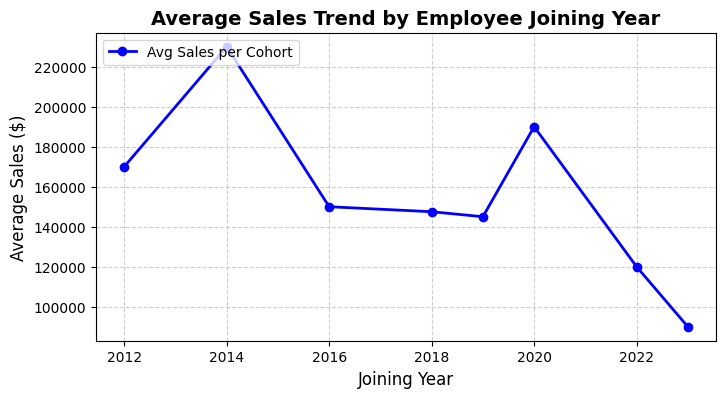

In [ ]:
# Prepare Data: Average sales per Joining Year
yearly_sales = df_clean.groupby('JoiningYear')['Sales'].mean().sort_index()

# 1. Initialize the canvas
plt.figure(figsize=(8, 4))

# 2. Draw the Line Plot
plt.plot(yearly_sales.index, yearly_sales.values, color='blue', marker='o', linestyle='-', linewidth=2, label='Avg Sales per Cohort')

# 3. Add Titles, Labels, and Legends
plt.title('Average Sales Trend by Employee Joining Year', fontsize=14, fontweight='bold')
plt.xlabel('Joining Year', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Render
plt.show()


## Module 2: Bar Plot


* **Business Question:** Which Department is driving the highest total sales for the company?
* **Data Impact:** Bar charts are for comparing categorical groups.


Used for comparing categorical magnitudes.

**$Parameters**

-> color: The fill color of the bars. Can be a single color or a list of colors mapped to each bar.

-> edgecolor: The color of the bar's border. Real-world use: Adding edgecolor='black' separates bars of the same color that are packed closely together.

-> width: Controls how thick the bars are (default is 0.8). If set to 1.0, the bars will touch each other.

-> bottom: Sets the baseline Y-coordinate for the bar. Real-world use: This is the parameter you use to build Stacked Bar Charts (e.g., placing the "Q2 Sales" bar directly on top of the "Q1 Sales" bar).

-> yerr (or xerr): Adds statistical error bars to the top of the bars, representing variance or confidence intervals.

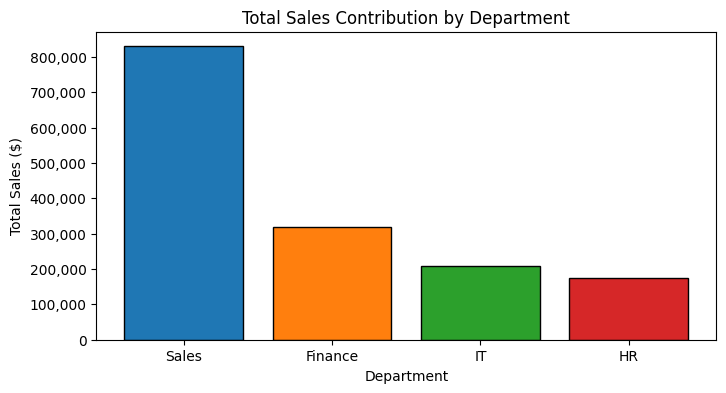

In [ ]:
# Prepare Data: Total sales per Department
dept_sales = df_clean.groupby('Department')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))

# Draw the Bar Plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
plt.bar(dept_sales.index, dept_sales.values, color=colors[:len(dept_sales)], edgecolor='black')

plt.title('Total Sales Contribution by Department')
plt.xlabel('Department')
plt.ylabel('Total Sales ($)')

# Formatting the Y-axis to show millions cleanly
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.show()


## Module 3: Histogram


* **Business Question:** What is the age distribution of our workforce?
* **Data Impact:** Histograms automatically bin continuous numerical data.


Used for observing the distribution and skewness of a single continuous feature.

$Parameters:

-> bins: Defines how many "buckets" to chop the data into. Can be an integer (e.g., bins=20) or a list of exact edges (bins=).

-> density: If True, it converts the Y-axis from "raw counts" to a "probability density" (the total area of the histogram equals 1). Essential for statistical modeling.

-> cumulative: If True, each bin adds the counts of the previous bins, creating a cumulative distribution curve.

-> color: The fill color of the bins.

-> edgecolor: The border of the bins. Real-world use: Always set edgecolor='white' or 'black' on histograms, otherwise the bins blend into one solid block.

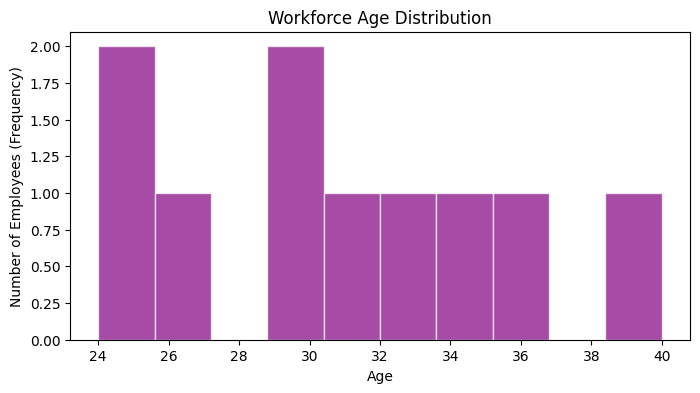

In [ ]:
plt.figure(figsize=(8, 4))

# Draw the Histogram
plt.hist(df_clean['Age'], bins=10, color='purple', edgecolor='white', alpha=0.7)

plt.title('Workforce Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Employees (Frequency)')

plt.show()


## Module 4: Scatter Plot


* **Business Question:** Does paying a higher salary actually guarantee higher sales?
* **Data Impact:** Spot clusters or linear correlations between two continuous variables.


Used for finding correlations or clusters in massive datasets.

**$Parametrs:**

-> s (Size): Controls the size of the dots. Real-world use: Passing a numerical array to s creates a Bubble Chart, where the size of the dot represents a third variable (like "Total Lifetime Spend").

-> c (Color): Sets the color. Like s, you can pass a numerical array to c to color-code dots based on a variable (like "Age").

-> cmap (Colormap): If you passed an array to c, cmap tells Matplotlib which color gradient to use (e.g., 'viridis', 'coolwarm').

-> alpha: Transparency. Real-world use: CRITICAL for dense datasets. If you have 10,000 dots, they will form a solid blob. Setting alpha=0.2 makes dense clusters appear darker, revealing true data density.

-> marker: Changes the shape of the scatter points.

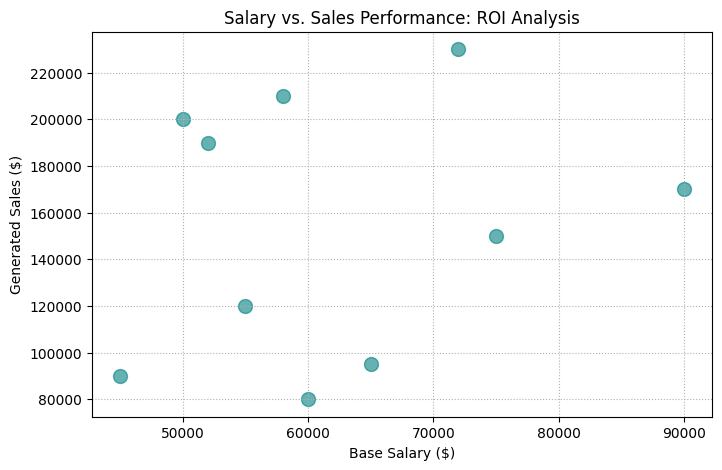

In [ ]:
plt.figure(figsize=(8, 5))

# Draw the Scatter Plot
plt.scatter(df_clean['Salary'], df_clean['Sales'], color='teal', alpha=0.6, s=100)

plt.title('Salary vs. Sales Performance: ROI Analysis')
plt.xlabel('Base Salary ($)')
plt.ylabel('Generated Sales ($)')
plt.grid(True, linestyle=':')

plt.show()


## Module 5: Pie Chart


* **Business Question:** What percentage of our staff is rated as "Excellent", "Good", or "Average"?
* **Data Impact:** Pass raw counts to calculate 360-degree percentages.


Used for showing composition or market share.

**$Parameters**

-> labels: A list of strings providing the name for each slice (e.g., ['North', 'South', 'East']).

-> autopct: A string format that automatically calculates and displays the percentages inside the slices (e.g., '%1.1f%%' displays "45.2%").

-> explode: A tuple of fractions telling Matplotlib to pull specific slices out from the center. Real-world use: explode=(0.1, 0, 0) pulls the first slice out slightly to draw attention to the winning region.

-> startangle: Rotates the start of the pie chart (default starts at 3 o'clock). Setting startangle=90 starts it at the top (12 o'clock), making it easier for humans to read.

-> shadow: If True, adds a 3D drop shadow beneath the chart.

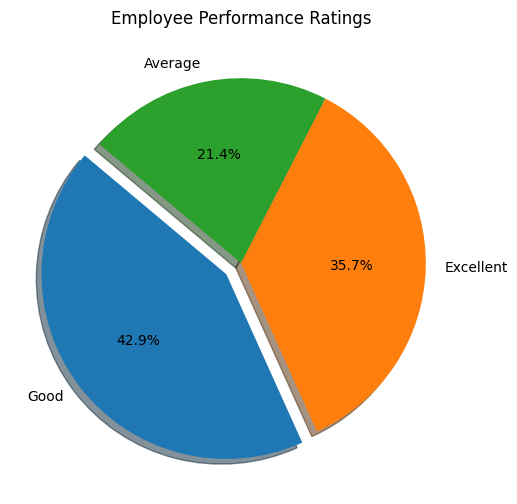

In [ ]:
import matplotlib.pyplot as plt

# Prepare Data
perf_counts = df['Performance'].dropna().value_counts()

plt.figure(figsize=(6, 6))

# Draw the Pie Chart
plt.pie(perf_counts.values, labels=perf_counts.index, autopct='%1.1f%%',
        startangle=140, explode=[0.1] + [0] * (len(perf_counts) - 1), shadow=True)

plt.title('Employee Performance Ratings')

plt.show()

## Module 6: Subplots and Plot Customization


* **Business Task:** Create a single, customized dashboard (Figure) containing multiple charts (Axes) side-by-side.
* **Data Impact:** `plt.subplots` creates a grid and returns `fig` and `axes`.


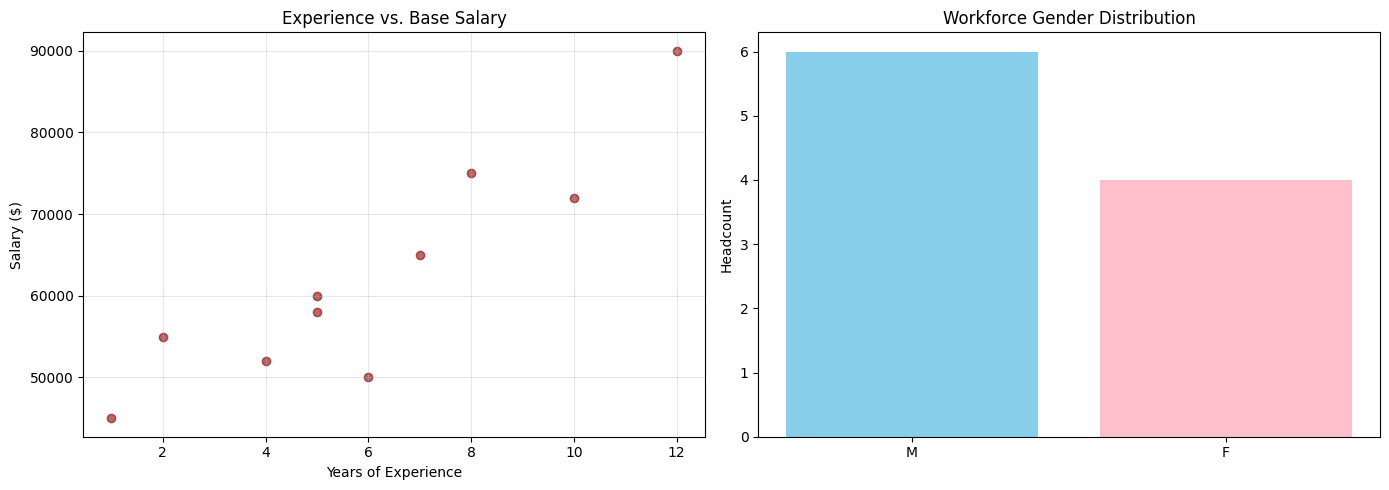

In [ ]:
# Create a 1-Row by 2-Column canvas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Plot 1 (Left Side: axes[0]) - Experience vs Salary
axes[0].scatter(df_clean['Experience'], df_clean['Salary'], color='darkred', alpha=0.6)
axes[0].set_title('Experience vs. Base Salary', fontsize=12)
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary ($)')
axes[0].grid(True, alpha=0.3)

# Plot 2 (Right Side: axes[1]) - Gender Distribution
gender_counts = df_clean['Gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['skyblue', 'pink', 'lightgrey'][:len(gender_counts)])
axes[1].set_title('Workforce Gender Distribution', fontsize=12)
axes[1].set_ylabel('Headcount')

# Module 7: Customization
plt.tight_layout()

# Render dashboard
plt.show()

### Logic Check / Execution Review

**Gotcha Question:** In the Subplots code, we used `axes.set_title()` instead of `plt.title()`. Why does the syntax change when we build a dashboard?

*(Answer: `plt.title()` is a "state-based" command; it blindly applies the title to whichever chart was drawn most recently in the computer's memory. When building multiple subplots, this is dangerous and unpredictable. By using the Object-Oriented approach (`axes.set_title()`), we are explicitly telling the memory exactly which quadrant of the dashboard should receive the title, ensuring total control.)*


## Top 20 Essential Matplotlib Methods & Attributes



**Phase 1: Canvas Setup & Subplots**
1. `plt.figure()`: Initializes a high-resolution canvas.
2. `plt.subplots()`: Instantiates both a Figure object and a grid of Axes objects simultaneously.

**Phase 2: Core Geometries (The Plots)**

3. `plt.plot()`: Connects discrete X, Y data points with continuous lines (Time-Series).
4. `plt.bar()` / `plt.barh()`: Draws vertical or horizontal rectangles for categorical comparisons.
5. `plt.scatter()`: Plots individual, unconnected dots to detect correlations.
6. `plt.hist()`: Automatically bins continuous numerical data and counts frequencies.
7. `plt.pie()`: Calculates proportional slices of a 360-degree circle.
8. `plt.boxplot()`: Identifies statistical outliers using median, quartiles, and whiskers.

**Phase 3: Context & Customization**

9. `plt.title()` / `ax.set_title()`: Gives the chart a business context.
10. `plt.xlabel()` / `plt.ylabel()`: Defines what the axes represent.
11. `plt.legend()`: Differentiates multiple trends on the same grid.
12. `plt.xticks()` / `plt.yticks()`: Formats tick labels (e.g., rotating text).
13. `plt.xlim()` / `plt.ylim()`: Zooms in by forcing graph boundaries.
14. `plt.grid()`: Adds faint background lines.
15. `plt.axhline()` / `plt.axvline()`: Draws a solid reference line across the chart.
16. `plt.annotate()`: Points an arrow and adds text to a specific data point.

**Phase 4: Styling & Palettes**

17. `plt.style.use()`: Changes the chart's aesthetic theme.
18. `plt.tight_layout()`: Automatically calculates padding so text doesn't bleed off the edge.

**Phase 5: Output**

19. `plt.show()`: Renders the graphic to your screen.
20. `plt.savefig()`: Exports the final graph as a `.png` or `.pdf`.


# 4) Seaborn



Welcome to Seaborn. If Matplotlib is the raw engineering engine for drawing pixels, **Seaborn** is the automated statistical wrapper built on top of it.

Seaborn’s superpower is its deep integration with Pandas. Instead of manually looping through data to assign colors to different categories, Seaborn does it instantly using the `hue` parameter. It also automatically calculates statistical confidence intervals.


## Setup: The Data
We will continue using the **HR & Sales Dataset** context.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn's global aesthetic theme (bypasses Matplotlib's default styling)
sns.set_theme(style="whitegrid", palette="muted")

# Re-loading our clean dataset (Make sure 'employee_sales_dataset.csv' is uploaded)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/employee_sales_dataset.csv')
df_clean = df.dropna(subset=['Sales', 'Salary', 'Experience', 'Age', 'JoiningYear'])


## Module 1 & 2: Distribution Plots and Count Plots



**Concept Introduction:** * `sns.histplot()` (Distribution): Replaces the old `distplot`. It shows the distribution of a continuous variable.
* `sns.countplot()` (Count): The equivalent of a bar plot, but you don't need to use `.groupby()` first. You just pass a raw categorical column, and Seaborn counts the occurrences automatically.

**Top 6 Parameters for `histplot` & `countplot`:**
1. **`data`**: The Pandas DataFrame you are passing in.
2. **`x` or `y`**: The specific column name (string) you want to plot. (Using `y` in a countplot makes the bars horizontal).
3. **`hue` (CRITICAL)**: A categorical column name. Seaborn will automatically split the data, assign different colors, and build a legend based on this column.
4. **`kde`** *(histplot only)*: If `True`, overlays a smooth Kernel Density Estimate curve over the histogram bars.
5. **`bins`** *(histplot only)*: The number of buckets to divide continuous data into.
6. **`order`** *(countplot only)*: A list specifying the exact order you want the categorical bars to appear (e.g., `['Excellent', 'Good', 'Average']`).


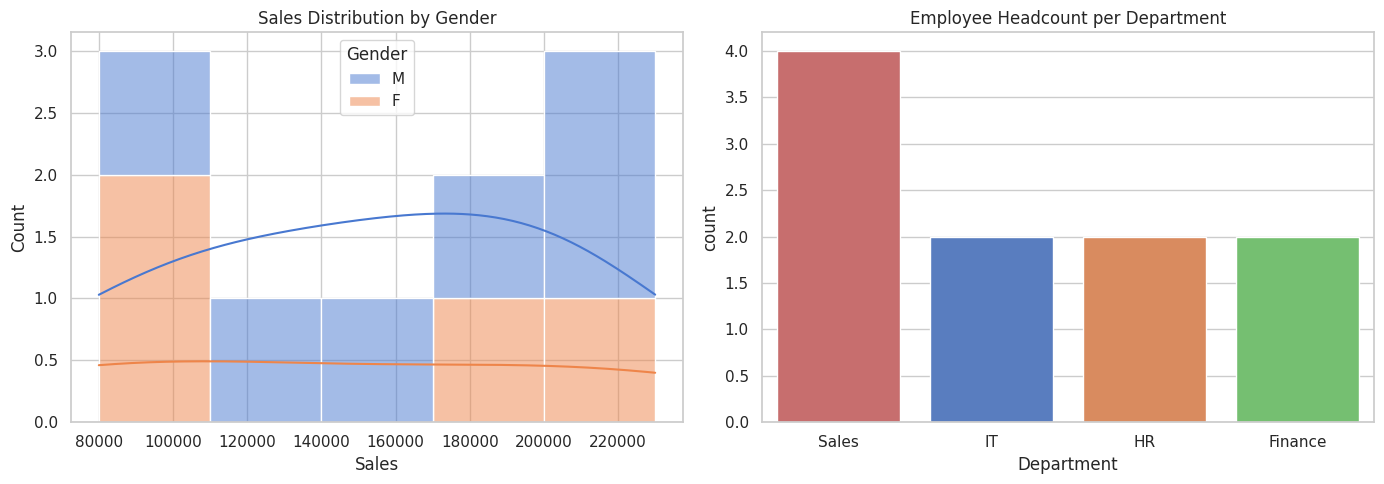

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution Plot (Module 1)
# Business Question: How are our sales distributed, and how does gender factor in?
sns.histplot(
    data=df_clean,
    x='Sales',
    hue='Gender',      # Automatically colors bars by Gender
    multiple="stack",  # Stacks the colors on top of each other
    kde=True,          # Adds the smooth trendline
    ax=axes[0]
)
axes[0].set_title('Sales Distribution by Gender')

# Plot 2: Count Plot (Module 2)
# Business Question: How many employees do we have per department?
sns.countplot(
    data=df_clean,
    x='Department',
    hue='Department',
    order=df_clean['Department'].value_counts().index, # Sorts bars highest to lowest
    ax=axes[1]
)
axes[1].set_title('Employee Headcount per Department')

plt.tight_layout()
plt.show()

## Module 3 & 4: Box Plots and Violin Plots



**Concept Introduction:** Both plots show the distribution of data across different categories.
* **Box Plot:** Focuses on rigid statistics (Median, Interquartile Range, and exact Outliers).
* **Violin Plot:** Combines a box plot with a KDE density curve. It shows the *shape* of the data (where the data is "thickest").

**Top 6 Parameters for `boxplot` & `violinplot`:**
1. **`data`**: The DataFrame.
2. **`x` and `y`**: Usually, `x` is categorical (e.g., 'Department') and `y` is continuous (e.g., 'Salary').
3. **`hue`**: Adds a third dimension (e.g., separating each Department's box into 'Male' and 'Female' boxes).
4. **`split`** *(violinplot only)*: If `hue` has exactly two categories (like M/F), setting `split=True` draws half of the violin for Male and the other half for Female, saving space.
5. **`inner`** *(violinplot only)*: Defines what is drawn inside the violin (`'box'` for a mini boxplot, `'quartile'` for dashed lines, `'point'` for raw dots).
6. **`showfliers`** *(boxplot only)*: If `False`, hides the outlier dots to focus on the core IQR.


/tmp/ipykernel_4389/1257200825.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='lower right', title='Performance')


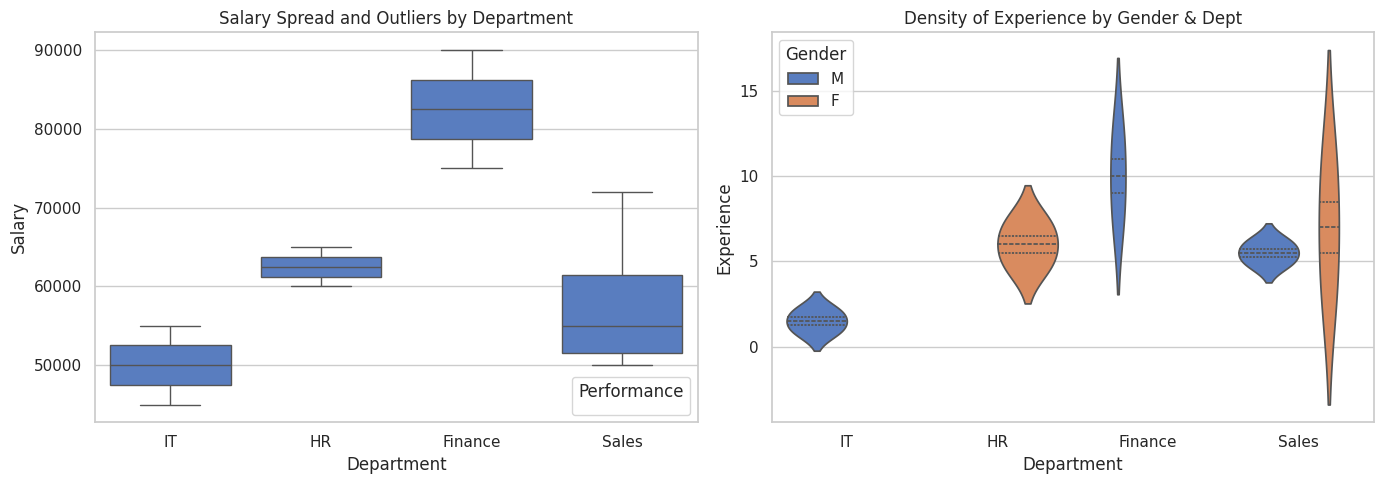

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Box Plot (Module 3)
# Business Question: Are there any statistical anomalies in Salaries across departments?
sns.boxplot(
    data=df_clean,
    x='Department',
    y='Salary',
    #hue='Performance',
    ax=axes[0]
)
axes[0].set_title('Salary Spread and Outliers by Department')
axes[0].legend(loc='lower right', title='Performance')

# Plot 2: Violin Plot (Module 4)
# Business Question: What is the shape of Experience levels based on Gender?
sns.violinplot(
    data=df_clean,
    x='Department',
    y='Experience',
    hue='Gender',
    #split=True,       # Merges the M/F violins into a single shape
    inner='quartile', # Shows quartile lines inside the violin
    ax=axes[1]
)
axes[1].set_title('Density of Experience by Gender & Dept')

plt.tight_layout()
plt.show()

## Module 5 & 8: Pair Plot and Statistical Plotting (`lmplot`)



**Concept Introduction:** * **`pairplot`**: The ultimate exploratory data analysis (EDA) tool. It takes every numeric column in your dataset and plots them against each other in a massive grid.
* **`lmplot` (Linear Model Plot)**: A scatter plot that automatically calculates and draws a Linear Regression best-fit line, complete with a translucent 95% confidence interval shadow.

**Top 6 Parameters for `pairplot` & `lmplot`:**
1. **`data`**: The DataFrame.
2. **`hue`**: Color-codes the entire matrix or regression line by a category.
3. **`corner`** *(pairplot only)*: If `True`, removes the upper triangle of the grid (which is just a mirror of the lower triangle), saving render time and visual clutter.
4. **`vars`** *(pairplot only)*: A list of specific columns to plot. (If omitted, it plots *all* numerical columns, which can crash your RAM on large datasets).
5. **`col` / `row`** *(lmplot only)*: Creates a completely separate subplot grid for every category (e.g., `col='Department'` creates a separate scatter plot for IT, HR, etc.).
6. **`ci`** *(lmplot only)*: The size of the confidence interval (default is 95). Set to `None` to turn off the shadow and speed up rendering.


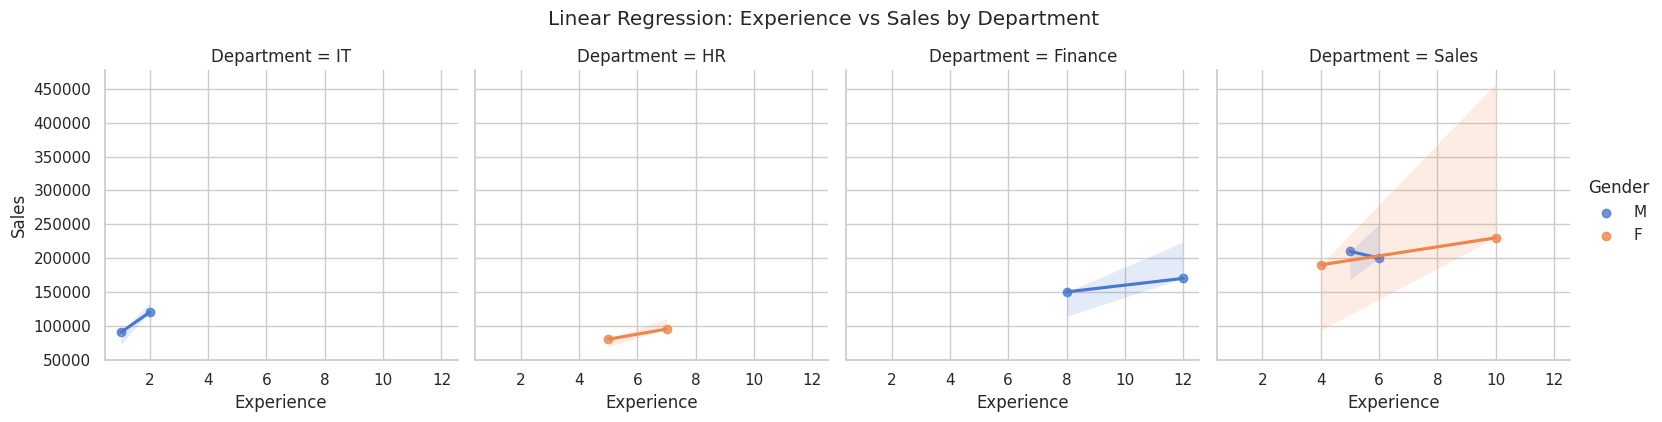

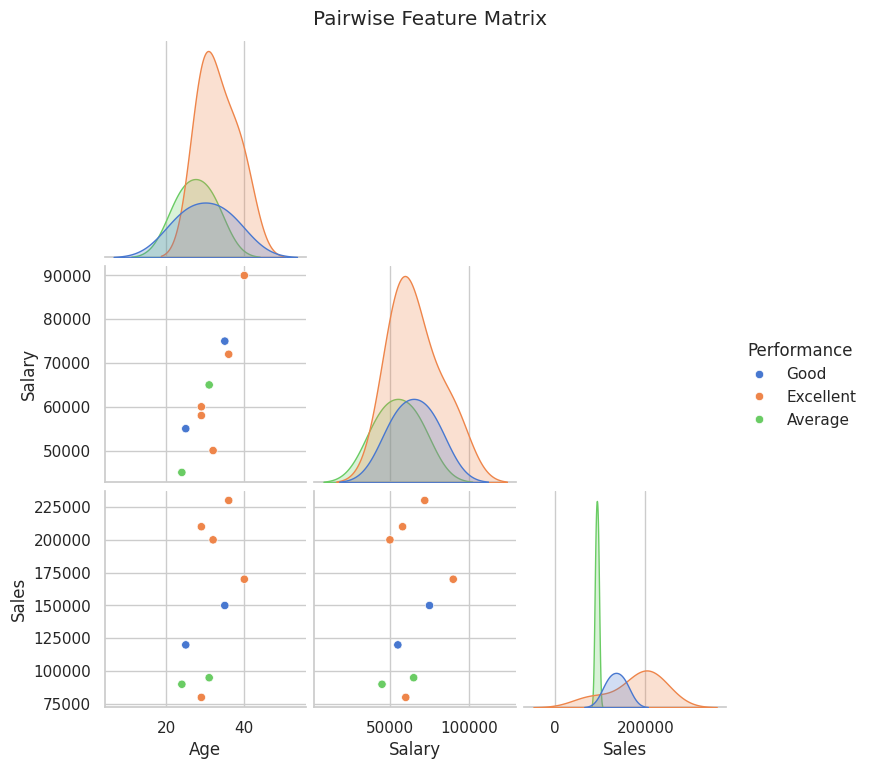

In [ ]:
# Plot 1: Statistical Plotting (Module 8)
# Business Question: Does Experience linearly predict Sales? Is the trend different for Men vs Women?
sns.lmplot(
    data=df_clean,
    x='Experience',
    y='Sales',
    hue='Gender',
    col='Department', # Creates side-by-side charts automatically!
    height=4,
    ci=95             # 95% Confidence Interval shadow
)
plt.suptitle('Linear Regression: Experience vs Sales by Department', y=1.05)
plt.show()

# Plot 2: Pair Plot (Module 5)
# Business Question: What do the relationships between Age, Salary, and Sales look like at a glance?
sns.pairplot(
    data=df_clean,
    vars=['Age', 'Salary', 'Sales'], # Restricting features to save memory
    hue='Performance',
    corner=True,                     # Removes duplicate mirror plots
    diag_kind='kde'                  # Uses density curves for the diagonal axis
)
plt.suptitle('Pairwise Feature Matrix', y=1.02)
plt.show()


## Module 6 & 7: Correlation Visualization & Heatmaps



**Concept Introduction:** Machine Learning models require features that are correlated with the target (Sales), but *not* perfectly correlated with each other (Multicollinearity). We use Pandas `.corr()` to calculate the mathematical correlation matrix (-1.0 to 1.0), and a Seaborn Heatmap to visualize it.

**Top 6 Parameters for `heatmap`:**
1. **`data`**: Must be a 2D matrix (like `df.corr()`), *not* a raw DataFrame.
2. **`annot` (Annotation)**: If `True`, writes the exact numerical value inside every colored square.
3. **`cmap` (Colormap)**: The color gradient. For correlation, a diverging map like `'coolwarm'` or `'RdBu'` is standard (Blue = negative, Red = positive, White = zero).
4. **`fmt`**: String formatting for the annotations (e.g., `'.2f'` ensures numbers only have 2 decimal places).
5. **`linewidths`**: Adds a grid line of a specific width between the squares to make it readable.
6. **`vmin` & `vmax`**: Forces the color scale to anchor at specific values (e.g., `-1.0` and `1.0` for correlation matrices) so the colors are always mathematically accurate.


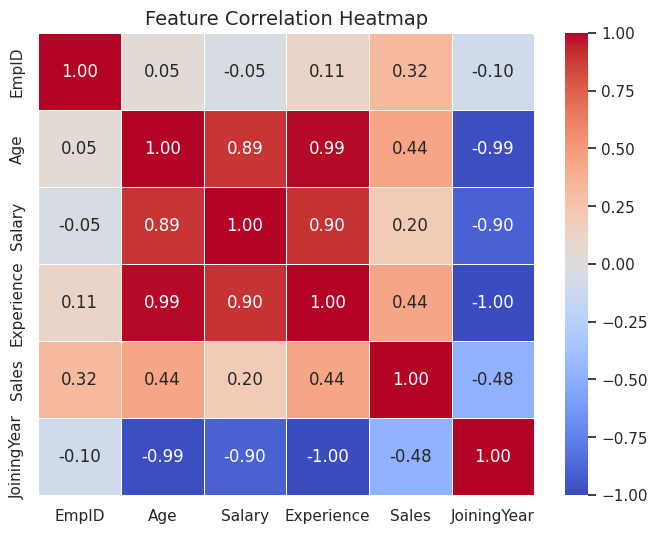

In [ ]:
plt.figure(figsize=(8, 6))

# Prepare Data: Module 7 (Correlation Calculation)
# We must select only numeric columns, or .corr() will throw an error.
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# Draw the Heatmap (Module 6)
# Business Question: Which numerical feature is the strongest predictor of Sales?
sns.heatmap(
    data=corr_matrix,
    annot=True,       # Show numbers
    cmap='coolwarm',  # Red = Positive Correlation, Blue = Negative
    fmt='.2f',        # 2 Decimal places
    linewidths=0.5,   # Gridlines
    vmin=-1, vmax=1   # Anchor the math scale
)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()


### Logic Check / Execution Review

**Gotcha Question:** You have a dataset of 1,000,000 rows. Your manager asks you to quickly check the correlation between all 50 numerical columns. You run `sns.pairplot(df)`. Your computer freezes and crashes. Why did this happen, and what should you have used instead?

*(Answer: `pairplot()` attempts to render a physical scatter plot for every single combination of variables. For 50 columns, that is 50 x 50 = 2,500 individual scatter plots, each containing 1 million dots. This exhausts your RAM instantly. To find correlations in massive datasets, you should rely entirely on `sns.heatmap(df.corr())`. The heatmap aggregates the math first, rendering a simple 50x50 grid of colored squares regardless of how many millions of rows exist in the raw data.)*
